# Step 3-1 (A) : XGBoost Walk-Forward — Q, Ω 계산

> **목적**: ETF 22종 Long-Panel 데이터로 XGBoost 분류 모델을 Walk-Forward 방식으로 학습하고,
> Black-Litterman 입력값인 **Q** (기대수익률)와 **Ω** (뷰 불확실성)를 추출한다.

---

### Walk-Forward 구조 (Lopez de Prado, 2018)

```
│◀──── IS: 252일 ────▶│◀ Embargo: 21일 ▶│◀ OOS: 21일 ▶│  → 21일씩 슬라이딩
총 윈도우 수 ≈ (전체 날짜 - 252) / 21 ≈ 97개
```

### 출력 파일

| 파일 | 내용 |
|------|------|
| `outputs/step3/xgb_Q_Omega.parquet` | OOS 전체 Q, Ω, 확률, 실제수익률 |
| `outputs/step3/Q_xgb.parquet` | BL 입력용 Q 피벗 (date × ticker) |
| `outputs/step3/Omega_xgb.parquet` | BL 입력용 Ω 피벗 (date × ticker) |

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor   # ← 분류 → 회귀 전환 (Gu-Kelly-Xiu 방식)
from sklearn.metrics import accuracy_score, log_loss
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path
from scipy.stats import spearmanr

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# ── 경로 설정 ──────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data")
OUTPUT_DIR = Path("outputs/step3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Walk-Forward 파라미터 ──────────────────────────────────────────────────────
IS_DAYS         = 504   # 학습 구간 (≈ 2거래년) — 금리 사이클·레짐 다양성 포착
EMBARGO_DAYS    = 21    # IS-OOS 경계 엠바고 (Lopez de Prado)
OOS_DAYS        = 21    # 예측 구간
N_OPTUNA_TRIALS = 30    # Optuna 탐색 횟수
RANDOM_STATE    = 42

print("✅ 설정 완료")
print(f"  IS={IS_DAYS}일(≈2년) | Embargo={EMBARGO_DAYS}일 | OOS={OOS_DAYS}일")
print(f"  목표변수: 연속 수익률 회귀 (XGBRegressor + Huber loss)")
print(f"  출력 경로: {OUTPUT_DIR.resolve()}")

## 2. 데이터 로드

Step2에서 저장된 `long_panel.parquet` 로드.  
Multi-Index: `[date, ticker]` / 타겟: `target_fwd` (21일 포워드 로그수익률)

In [2]:
# parquet 우선, 없으면 csv 시도
try:
    panel = pd.read_parquet(DATA_DIR / "long_panel.parquet")
    print("✅ parquet 로드 성공")
except FileNotFoundError:
    panel = pd.read_csv(DATA_DIR / "df_panel.csv", parse_dates=["Date"])
    panel = panel.rename(columns={"Date": "date", "Ticker": "ticker"})
    panel = panel.set_index(["date", "ticker"])
    print("✅ csv 로드 성공")

panel = panel.sort_index()

print(f"\nPanel shape : {panel.shape}")
print(f"날짜 범위   : {panel.index.get_level_values('date').min().date()} "
      f"~ {panel.index.get_level_values('date').max().date()}")
print(f"ETF 수      : {panel.index.get_level_values('ticker').nunique()}")
print(f"고유 날짜 수: {panel.index.get_level_values('date').nunique()}")
print(f"\n컬럼 목록: {panel.columns.tolist()}")

✅ csv 로드 성공

Panel shape : (51612, 36)
날짜 범위   : 2017-01-04 ~ 2025-12-31
ETF 수      : 22
고유 날짜 수: 2346

컬럼 목록: ['asset_class', 'sub_class', 'price', 'ret', 'ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'vol_21d', 'vol_63d', 'vol_ratio', 'beta_60d', 'beta_120d', 'rate_corr_60d', 'rsi_14d', 'VIX_level', 'VIX_contango', 'VIX_slope_9d_3m', 'VIX_slope_3m_6m', 'SKEW_level', 'SKEW_zscore', 'Cu_Au_ratio', 'Cu_Au_ratio_chg', 'HY_spread', 'HY_spread_chg', 'yield_curve', 'yield_curve_inv', 'claims_4wma', 'claims_zscore', 'WEI_level', 'sahm_indicator', 'DGS10_chg5', 'fwd_ret_5d', 'fwd_ret_21d', 'fwd_ret_63d', 'fwd_label_21d']


In [3]:
# 결측치 현황
missing = panel.isnull().mean().sort_values(ascending=False)
print("결측치 비율 (> 0인 컬럼만):")
print(missing[missing > 0].to_string())

결측치 비율 (> 0인 컬럼만):
fwd_ret_63d      0.026854
fwd_ret_21d      0.008951
fwd_label_21d    0.008951
fwd_ret_5d       0.002131
rsi_14d          0.000116


## 3. 피처 / 타겟 정의

In [4]:
TARGET_COL = "fwd_ret_21d"  # Step2 산출물 컬럼명
SECTOR_COL = "asset_class"  # Step2 산출물 컬럼명 (equity / bond / alt / equity_sector)

# ── 자산별 피처 (모멘텀·변동성·베타·민감도) ──────────────────────────────────
ASSET_FEATURES = [
    "ret_1m", "ret_3m", "ret_6m", "ret_12m",
    "vol_21d", "vol_63d", "vol_ratio",
    "beta_60d", "beta_120d",
    "rate_corr_60d", "rsi_14d",
]

# ── 매크로 피처 17개 ──────────────────────────────────────────────────────────
MACRO_FEATURES = [
    "VIX_level", "VIX_contango", "VIX_slope_9d_3m", "VIX_slope_3m_6m",
    "SKEW_level", "SKEW_zscore",
    "Cu_Au_ratio", "Cu_Au_ratio_chg",
    "HY_spread", "HY_spread_chg",
    "yield_curve", "yield_curve_inv",
    "claims_4wma", "claims_zscore",
    "WEI_level", "sahm_indicator",
    "DGS10_chg5",
]

# ── GDELT 감성 피처 (수집 완료 후 자동 추가) ──────────────────────────────────
GDELT_FEATURES = [
    "gdelt_avg_tone_1m", "gdelt_tone_momentum", "gdelt_article_volume",
]

# ── HMM 레짐 확률 (Step2에 추가되면 자동 추가) ────────────────────────────────
HMM_FEATURES = ["hmm_crisis_prob"]

# ── 수치형 전체 (SECTOR_COL 제외) ────────────────────────────────────────────
NUM_FEATURES = ASSET_FEATURES + MACRO_FEATURES + GDELT_FEATURES + HMM_FEATURES
ALL_FEATURES = NUM_FEATURES + [SECTOR_COL]

# ── 실제 존재하는 컬럼만 사용 (GDELT/HMM 수집 전 graceful 처리) ──────────────
available_num = [c for c in NUM_FEATURES if c in panel.columns]
available_cat = [SECTOR_COL] if SECTOR_COL in panel.columns else []
FINAL_FEATURES = available_num + available_cat

missing_cols = [c for c in ALL_FEATURES if c not in panel.columns]

print(f"수치형 피처: {len(available_num)}개")
print(f"카테고리 피처: {len(available_cat)}개  →  {available_cat}")
print(f"총 피처: {len(FINAL_FEATURES)}개")
if missing_cols:
    print(f"\n⚠️  아직 없는 피처 (수집 후 자동 추가됨): {missing_cols}")

수치형 피처: 28개
카테고리 피처: 1개  →  ['asset_class']
총 피처: 29개

⚠️  아직 없는 피처 (수집 후 자동 추가됨): ['gdelt_avg_tone_1m', 'gdelt_tone_momentum', 'gdelt_article_volume', 'hmm_crisis_prob']


## 3-1. 피처 정규화 (Gu-Kelly-Xiu 2020)

> **"We cross-sectionally rank all stock characteristics period-by-period and map these ranks into the [-1, 1] interval"**

| 피처 종류 | 정규화 방법 | 이유 |
|---|---|---|
| 자산별 (모멘텀·변동성·베타) | **날짜별 cross-sectional rank → [-1, 1]** | ETF 간 상대 서열 학습, 레짐 불변 |
| 매크로 (VIX·HY·금리 등) | **롤링 252일 z-score** | 절대값 레짐 의존성 제거 (VIX=25가 2017=높음, 2020=낮음) |

In [ ]:
# ── 자산별 피처: 날짜별 cross-sectional rank → [-1, 1] ────────────────────────
# 같은 날짜의 22개 ETF 중 상대 서열만 학습 → 레짐 전환 시 신호 반전 방지
ASSET_NORM_COLS = [c for c in ASSET_FEATURES if c in panel.columns]

panel_norm = panel.copy()
for col in ASSET_NORM_COLS:
    panel_norm[col] = (
        panel_norm.groupby(level='date')[col]
        .transform(lambda x: 2 * x.rank(pct=True, na_option='keep') - 1)
    )

# ── 매크로 피처: 롤링 252일 z-score ──────────────────────────────────────────
# 모든 ETF가 동일한 매크로값 → cross-sectional 정규화 불가 → 시계열 정규화
MACRO_NORM_COLS = [c for c in MACRO_FEATURES if c in panel.columns]

for col in MACRO_NORM_COLS:
    # 날짜별 단일 시계열 추출 (22개 ETF 동일값이므로 first()로 대표값 사용)
    date_series = panel_norm[col].groupby(level='date').first().sort_index()
    roll_mean   = date_series.rolling(252, min_periods=63).mean()
    roll_std    = date_series.rolling(252, min_periods=63).std().replace(0, np.nan).fillna(1e-8)
    zscore_map  = ((date_series - roll_mean) / roll_std).to_dict()
    date_idx    = panel_norm.index.get_level_values('date')
    panel_norm[col] = date_idx.map(zscore_map)

panel = panel_norm
del panel_norm

# ── 정규화 결과 검증 ─────────────────────────────────────────────────────────
sample_asset = ASSET_NORM_COLS[0] if ASSET_NORM_COLS else None
sample_macro = MACRO_NORM_COLS[0] if MACRO_NORM_COLS else None
print("✅ 피처 정규화 완료")
print(f"  Cross-sectional rank: {len(ASSET_NORM_COLS)}개 → {ASSET_NORM_COLS}")
print(f"  Rolling z-score     : {len(MACRO_NORM_COLS)}개 → {MACRO_NORM_COLS[:4]}...")
if sample_asset:
    s = panel[sample_asset].dropna()
    print(f"\n  {sample_asset}: min={s.min():.3f} | max={s.max():.3f} | mean={s.mean():.3f}")
if sample_macro:
    s = panel[sample_macro].dropna()
    print(f"  {sample_macro}: min={s.min():.3f} | max={s.max():.3f} | mean={s.mean():.3f}")

## 4. Walk-Forward 날짜 윈도우 생성

**슬라이딩 방식**: IS 시작점을 OOS_DAYS씩 이동

```
Window 0:  IS[0:252]   →  Embargo[252:273]  →  OOS[273:294]
Window 1:  IS[21:273]  →  Embargo[273:294]  →  OOS[294:315]
...
```

> 💡 패널이 **월별** 주기라면 `IS_DAYS=7, EMBARGO_DAYS=1, OOS_DAYS=1` 로 재설정하세요.

In [5]:
dates_arr = (panel.index
            .get_level_values("date")
            .unique()
            .sort_values()
            .to_numpy())
n_dates = len(dates_arr)

windows = []
i = 0
while True:
    oos_end = i + IS_DAYS + EMBARGO_DAYS + OOS_DAYS
    if oos_end > n_dates:
        break
    windows.append({
        "window_id"     : len(windows),
        "is_dates"      : dates_arr[i : i + IS_DAYS],
        "emb_dates"     : dates_arr[i + IS_DAYS : i + IS_DAYS + EMBARGO_DAYS],
        "oos_dates"     : dates_arr[i + IS_DAYS + EMBARGO_DAYS : oos_end],
        "oos_start_date": dates_arr[i + IS_DAYS + EMBARGO_DAYS],
        "oos_end_date"  : dates_arr[oos_end - 1],
    })
    i += OOS_DAYS  # 슬라이딩

print(f"총 날짜 수  : {n_dates}")
print(f"총 윈도우 수: {len(windows)}")
print("\n[윈도우 샘플]")
for w in windows[:3]:
    print(f"  W{w['window_id']:02d}: IS {w['is_dates'][0]!s:.10s}~{w['is_dates'][-1]!s:.10s} "
          f"| OOS {w['oos_start_date']!s:.10s}~{w['oos_end_date']!s:.10s}")
print("  ...")

총 날짜 수  : 2346
총 윈도우 수: 98

[윈도우 샘플]
  W00: IS 2017-01-04~2017-12-21 | OOS 2018-01-22~2018-02-19
  W01: IS 2017-02-02~2018-01-19 | OOS 2018-02-20~2018-03-20
  W02: IS 2017-03-03~2018-02-19 | OOS 2018-03-21~2018-04-18
  ...


## 5. 핵심 헬퍼 함수

In [ ]:
def build_X(df, num_cols, cat_col=None):
    """feature DataFrame 구성. cat_col → category dtype (XGBoost enable_categorical용)."""
    X = df[num_cols].fillna(0).copy()
    if cat_col and cat_col in df.columns:
        X[cat_col] = df[cat_col].astype('category')
    return X


def r2_oos(y_true, y_pred):
    """
    OOS R² (Gu-Kelly-Xiu 2020 방식):
      분모 = Σr²  ← 나이브 예측(항상 0)을 벤치마크
    종래 R²(분모=분산)와 달리, 수익률 평균이 0이 아닌 경우 더 엄격한 기준.
    """
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum(y_true ** 2)   # 벤치마크 = 0 (not mean)
    return 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan


print("helper functions defined")

## 6. Optuna 하이퍼파라미터 탐색 함수

In [ ]:
def make_objective(X_tr, y_tr, val_ratio=0.2, embargo_days=21):
    """
    Optuna objective 팩토리 (회귀 버전).
    IS를 80/20 시간 순 분할 → RMSE 최소화.
    """
    row_dates    = pd.DatetimeIndex(X_tr.index.get_level_values('date'))
    unique_dates = row_dates.unique().sort_values()
    n_dates      = len(unique_dates)

    val_start_idx = int(n_dates * (1 - val_ratio))
    train_end_idx = max(val_start_idx - embargo_days, 1)

    train_cutoff   = unique_dates[train_end_idx - 1]
    val_start_date = unique_dates[val_start_idx]

    train_mask = (row_dates <= train_cutoff)
    val_mask   = (row_dates >= val_start_date)

    X_t, X_v = X_tr[train_mask], X_tr[val_mask]
    y_t, y_v = y_tr[train_mask], y_tr[val_mask]

    def objective(trial):
        params = dict(
            n_estimators         = trial.suggest_int("n_estimators", 100, 500),
            max_depth            = trial.suggest_int("max_depth", 3, 6),   # 얕게 (금융 데이터 low S/N)
            learning_rate        = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            subsample            = trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree     = trial.suggest_float("colsample_bytree", 0.5, 1.0),
            min_child_weight     = trial.suggest_int("min_child_weight", 1, 10),
            gamma                = trial.suggest_float("gamma", 0.0, 3.0),
            reg_lambda           = trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
            reg_alpha            = trial.suggest_float("reg_alpha", 1e-5, 1.0, log=True),
            # 고정값
            objective            = "reg:pseudohubererror",   # Huber loss (heavy tail 대응)
            eval_metric          = "rmse",
            tree_method          = "hist",
            enable_categorical   = True,
            random_state         = RANDOM_STATE,
            early_stopping_rounds= 20,
            n_jobs               = -1,
            verbosity            = 0,
        )
        model = XGBRegressor(**params)
        model.fit(X_t, y_t, eval_set=[(X_v, y_v)], verbose=False)
        pred_v = model.predict(X_v)
        return float(np.sqrt(np.mean((y_v - pred_v) ** 2)))

    return objective


print("✅ Optuna objective (회귀) 정의 완료")

## 7. Walk-Forward 메인 루프

각 윈도우마다:

1. **IS / OOS 분할** (엠바고 제외)
2. **피처 행렬 구성** — 이미 정규화된 panel 사용
3. **Optuna** 하이퍼파라미터 탐색 (IS 내부 80/20 시계열 분할, RMSE 기준)
4. **전체 IS**로 최종 XGBRegressor (Huber loss) 학습
5. **Q = 직접 예측값** (r̄_k 역산 불필요)
6. **Ω = IS MSE × IC 스케일링** (`Ω = σ²_r · (1-IC²)/IC²`)


In [ ]:
all_results     = []
window_stats    = []
best_params_log = []
final_model     = None

dates_level_idx = panel.index.get_level_values("date")

for window in tqdm(windows, desc="Walk-Forward"):
    wid = window["window_id"]

    # ── 1. IS / OOS 분할 ────────────────────────────────────────────────────
    is_dates_idx  = pd.DatetimeIndex(window["is_dates"])
    oos_dates_idx = pd.DatetimeIndex(window["oos_dates"])

    is_df  = panel[dates_level_idx.isin(is_dates_idx)].copy()
    oos_df = panel[dates_level_idx.isin(oos_dates_idx)].copy()

    is_df       = is_df.dropna(subset=[TARGET_COL])
    oos_pred_df = oos_df.dropna(subset=available_num)
    oos_eval_df = oos_df.dropna(subset=[TARGET_COL])

    # ── Purge: IS 마지막 OOS_DAYS 거래일 제거 ────────────────────────────────
    is_unique_dates = pd.DatetimeIndex(
        is_df.index.get_level_values('date').unique()
    ).sort_values()
    if len(is_unique_dates) > OOS_DAYS:
        purge_cutoff = is_unique_dates[-OOS_DAYS]
        is_df = is_df[
            pd.DatetimeIndex(is_df.index.get_level_values('date')) < purge_cutoff
        ]

    if len(is_df) < IS_DAYS // 2 or len(oos_pred_df) == 0:
        continue

    # ── 2. 피처 행렬 / 타겟 구성 (정규화된 panel 사용) ──────────────────────
    cat_col = available_cat[0] if available_cat else None
    X_is  = build_X(is_df, available_num, cat_col)
    X_oos = build_X(oos_pred_df, available_num, cat_col)
    y_is  = is_df[TARGET_COL].values          # 연속 수익률

    # ── 3. Optuna 탐색 ───────────────────────────────────────────────────────
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + wid),
    )
    study.optimize(
        make_objective(X_is, y_is),
        n_trials=N_OPTUNA_TRIALS,
        show_progress_bar=False,
    )

    best_p = study.best_params.copy()
    best_p.update({
        "objective"          : "reg:pseudohubererror",
        "eval_metric"        : "rmse",
        "tree_method"        : "hist",
        "enable_categorical" : True,
        "random_state"       : RANDOM_STATE,
        "n_jobs"             : -1,
        "verbosity"          : 0,
    })
    best_params_log.append({"window_id": wid, **best_p})

    # ── 4. 전체 IS로 최종 학습 ───────────────────────────────────────────────
    final_model = XGBRegressor(**best_p)
    final_model.fit(X_is, y_is, verbose=False)

    # ── 5. Q = 직접 예측값 (r̄_k 역산 불필요) ───────────────────────────────
    Q_arr = final_model.predict(X_oos)

    # ── 6. Ω = IS 잔차분산 × IC 스케일링 ────────────────────────────────────
    # 논문 공식: Ω = σ²_r · (1-IC²)/IC²
    is_pred = final_model.predict(X_is)
    is_mse  = float(np.mean((y_is - is_pred) ** 2))

    ic_is_val, _ = spearmanr(is_pred, y_is)
    ic_is_val    = float(ic_is_val) if np.isfinite(ic_is_val) else 0.0

    if abs(ic_is_val) > 0.05:
        omega_scale = (1.0 - ic_is_val ** 2) / (ic_is_val ** 2 + 1e-8)
    else:
        omega_scale = 1.0   # IC가 낮으면 최대 불확실성 부여

    Omega_arr = np.full(len(Q_arr), is_mse * omega_scale)

    # ── 7. OOS 평가 ──────────────────────────────────────────────────────────
    r2 = np.nan
    if len(oos_eval_df) > 0:
        pred_idx = oos_pred_df.index
        eval_idx = oos_eval_df.index
        common   = pred_idx.intersection(eval_idx)
        if len(common) > 0:
            pred_pos_map = {idx: pos for pos, idx in enumerate(pred_idx)}
            eval_pos_map = {idx: pos for pos, idx in enumerate(eval_idx)}
            pred_pos = [pred_pos_map[i] for i in common]
            eval_pos = [eval_pos_map[i] for i in common]
            r2 = r2_oos(
                oos_eval_df.iloc[eval_pos][TARGET_COL].values,
                Q_arr[pred_pos]
            )

    # ── 8. 행별 결과 저장 ────────────────────────────────────────────────────
    eval_ret_map = {idx: oos_eval_df.iloc[i2][TARGET_COL]
                    for i2, idx in enumerate(oos_eval_df.index)}

    for i, idx in enumerate(oos_pred_df.index):
        all_results.append({
            "date"      : idx[0],
            "ticker"    : idx[1],
            "Q"         : float(Q_arr[i]),
            "Omega"     : float(Omega_arr[i]),
            "actual_ret": eval_ret_map.get(idx, np.nan),
            "window_id" : wid,
        })

    window_stats.append({
        "window_id"        : wid,
        "oos_start"        : window["oos_start_date"],
        "oos_end"          : window["oos_end_date"],
        "is_size"          : len(is_df),
        "oos_size"         : len(oos_pred_df),
        "oos_r2"           : r2,
        "ic_is"            : ic_is_val,
        "omega_scale"      : omega_scale,
        "optuna_best_rmse" : study.best_value,
    })

print(f"✅ Walk-Forward 완료: {len(window_stats)}개 윈도우 처리")

## 8. 결과 집계 및 저장

In [ ]:
results_df = (pd.DataFrame(all_results)
              .set_index(["date", "ticker"])
              .sort_index())
stats_df   = pd.DataFrame(window_stats)
params_df  = pd.DataFrame(best_params_log)

results_df.to_parquet(OUTPUT_DIR / "xgb_Q_Omega.parquet")
stats_df.to_csv(OUTPUT_DIR / "xgb_window_stats.csv", index=False)
params_df.to_csv(OUTPUT_DIR / "xgb_best_params_log.csv", index=False)

print(f"xgb_Q_Omega.parquet     → shape {results_df.shape}")
print(f"xgb_window_stats.csv    → shape {stats_df.shape}")
print(f"xgb_best_params_log.csv → shape {params_df.shape}")

results_df.head(6)

## 9. 성과 요약 통계

In [ ]:
print("=" * 60)
print("  XGBoost Walk-Forward OOS 성과 요약 (회귀 모드)")
print("=" * 60)

r2_s  = stats_df["oos_r2"].dropna()
ic_s  = stats_df["ic_is"].dropna()

print(f"\n[R²_oos  (Q vs 실제수익률, 벤치마크=0, Gu-Kelly-Xiu 방식)]")
print(f"  평균         : {r2_s.mean():.4f}")
print(f"  중앙값       : {r2_s.median():.4f}")
print(f"  R²>0 비율    : {(r2_s>0).mean():.1%}  ← ML > 나이브 예측(0) 비율")
print(f"  범위         : {r2_s.min():.4f} ~ {r2_s.max():.4f}")

print(f"\n[IS IC (Spearman, 학습 구간 신호 품질)]")
print(f"  평균   : {ic_s.mean():.4f}")
print(f"  IC>0   : {(ic_s>0).mean():.1%}")

print(f"\n[Q / Ω 분포]")
print(f"  Q   평균: {results_df['Q'].mean():.5f}  std: {results_df['Q'].std():.5f}")
print(f"  Ω   평균: {results_df['Omega'].mean():.6f}  std: {results_df['Omega'].std():.6f}")

# 성과 판정
r2_mean = r2_s.mean()
ic_mean = ic_s.mean()
r2_pos  = (r2_s > 0).mean()
print(f"\n{'='*60}")
if r2_mean > 0 and r2_pos > 0.4:
    print("  ✅ 판정: OOS R² 양수 전환 — 정규화 효과 확인")
elif r2_mean > -0.1:
    print("  ⚠️  판정: R² 음수이나 기존 대비 개선 — IC 추가 모니터링")
else:
    print("  ❌ 판정: 여전히 R² 음수 — 피처 재검토 또는 IS 기간 추가 확대 필요")

## 9-1. Cross-Sectional IC (Information Coefficient)

R2_oos가 Q 절대값 정확도를 보는 반면, **IC는 같은 날짜에 Q 높은 ETF가 실제로 더 올랐는가 (상대 서열)**를 측정.
Black-Litterman에서 실질적으로 더 중요한 신호 품질 지표.

| 지표 | 의미 | 기준 |
|------|------|------|
| IC 평균 | Q 서열 vs 실제 수익률 서열의 평균 상관 | 0.05 이상이면 유의미 |
| ICIR | IC 평균 / IC 표준편차 (신호 일관성) | 0.5 이상이면 양호 |
| IC > 0 비율 | Q 서열이 맞은 날 비율 | 50% 이상이면 양호 |

  Cross-Sectional IC 분석
IC 평균  : -0.0200  (0.05 이상이면 유의미)
  IC std   : 0.3674
  ICIR     : -0.0546  (0.5 이상이면 양호, 1.0 이상이면 우수)
  IC > 0   : 48.1%  (50% 이상이면 양호)

  판정: 신호 없음 - 모델 재검토 필요


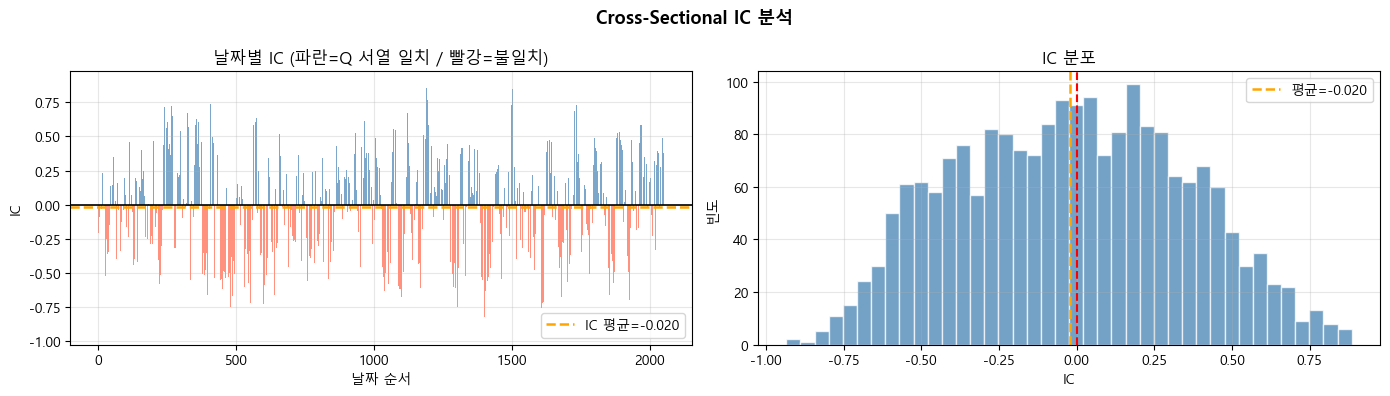

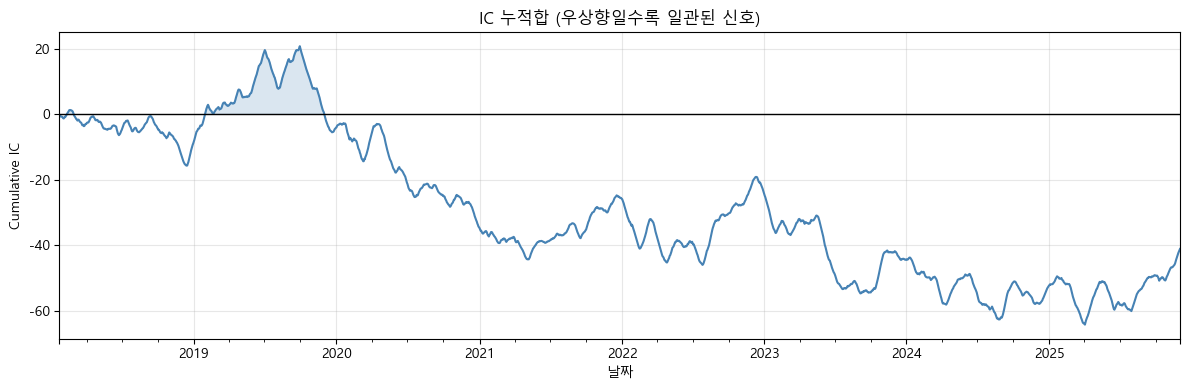

저장: outputs\step3


In [11]:
from scipy.stats import spearmanr

# ── 날짜별 크로스섹션 IC (Spearman) ──────────────────────────────────────────
def calc_ic(g):
    df = g.dropna(subset=["Q", "actual_ret"])
    if len(df) < 5:
        return np.nan
    return spearmanr(df["Q"], df["actual_ret"])[0]

ic_series = (
    results_df
    .groupby(level="date")
    .apply(calc_ic)
    .rename("IC")
    .dropna()
)

ic_mean = ic_series.mean()
ic_std  = ic_series.std()
icir    = ic_mean / ic_std if ic_std > 1e-12 else np.nan
ic_pos  = (ic_series > 0).mean()

print("=" * 50)
print("  Cross-Sectional IC 분석")
print("=" * 50)
print(f"IC 평균  : {ic_mean:.4f}  (0.05 이상이면 유의미)")
print(f"  IC std   : {ic_std:.4f}")
print(f"  ICIR     : {icir:.4f}  (0.5 이상이면 양호, 1.0 이상이면 우수)")
print(f"  IC > 0   : {ic_pos:.1%}  (50% 이상이면 양호)")
print()
if icir > 1.0:
    print("  판정: 우수한 크로스섹션 신호")
elif icir > 0.5:
    print("  판정: 양호한 크로스섹션 신호 - BL 활용 가능")
elif ic_mean > 0:
    print("  판정: 약한 신호 - BL에서 tau 작게 설정 권장")
else:
    print("  판정: 신호 없음 - 모델 재검토 필요")

# ── 시각화 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Cross-Sectional IC 분석", fontsize=13, fontweight="bold")

ax = axes[0]
colors = ["steelblue" if v > 0 else "tomato" for v in ic_series.values]
ax.bar(range(len(ic_series)), ic_series.values, color=colors, alpha=0.7)
ax.axhline(0,       color="black",  lw=1.2)
ax.axhline(ic_mean, color="orange", lw=1.8, ls="--", label=f"IC 평균={ic_mean:.3f}")
ax.set_title("날짜별 IC (파란=Q 서열 일치 / 빨강=불일치)")
ax.set_xlabel("날짜 순서"); ax.set_ylabel("IC")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(ic_series.values, bins=40, color="steelblue", alpha=0.75, edgecolor="white")
ax.axvline(0,       color="red",    lw=1.5, ls="--")
ax.axvline(ic_mean, color="orange", lw=1.8, ls="--", label=f"평균={ic_mean:.3f}")
ax.set_title("IC 분포")
ax.set_xlabel("IC"); ax.set_ylabel("빈도")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgb_IC_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── IC 누적합 (신호 일관성 확인) ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ic_series.cumsum().plot(ax=ax, color="steelblue", lw=1.5)
ax.axhline(0, color="black", lw=1)
ax.fill_between(ic_series.index, ic_series.cumsum(), 0,
                where=(ic_series.cumsum() > 0), alpha=0.2, color="steelblue")
ax.set_title("IC 누적합 (우상향일수록 일관된 신호)")
ax.set_xlabel("날짜"); ax.set_ylabel("Cumulative IC"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgb_IC_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {OUTPUT_DIR}")

## 10. 시각화

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("XGBoost Walk-Forward 성과 분석 (회귀 모드)", fontsize=14, fontweight="bold")

# (1) R²_oos by Window
ax = axes[0, 0]
colors_bar = ["limegreen" if v > 0 else "tomato"
               for v in stats_df["oos_r2"].fillna(0)]
ax.bar(stats_df["window_id"], stats_df["oos_r2"].fillna(0),
       color=colors_bar, alpha=0.75)
ax.axhline(0, color="black", lw=1.5)
ax.set_title("R²_oos  (녹색: ML > 나이브, 벤치마크=0)")
ax.set_xlabel("Window ID"); ax.set_ylabel("R²_oos"); ax.grid(alpha=0.3, axis="y")

# (2) IS IC by Window
ax = axes[0, 1]
colors_ic = ["steelblue" if v > 0 else "tomato"
              for v in stats_df["ic_is"].fillna(0)]
ax.bar(stats_df["window_id"], stats_df["ic_is"].fillna(0),
       color=colors_ic, alpha=0.75)
ax.axhline(0, color="black", lw=1.2)
ax.axhline(0.05, color="orange", lw=1.2, ls="--", label="IC=0.05 기준선")
ax.set_title("IS IC (학습 구간 Spearman 상관)")
ax.set_xlabel("Window ID"); ax.set_ylabel("IC"); ax.legend(); ax.grid(alpha=0.3, axis="y")

# (3) Q 분포
ax = axes[1, 0]
ax.hist(results_df["Q"], bins=60, color="steelblue", alpha=0.75, edgecolor="white")
ax.axvline(0, color="red", ls="--", lw=1.2)
ax.set_title("Q (예측 기대수익률) 분포")
ax.set_xlabel("Q"); ax.set_ylabel("빈도"); ax.grid(alpha=0.3)

# (4) Ω 분포
ax = axes[1, 1]
ax.hist(results_df["Omega"], bins=60, color="darkorange", alpha=0.75, edgecolor="white")
ax.set_title("Ω (예측 불확실성) 분포")
ax.set_xlabel("Ω"); ax.set_ylabel("빈도"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgb_walkforward_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {OUTPUT_DIR / 'xgb_walkforward_performance.png'}")

## 11. Q 히트맵 (ETF × 날짜)

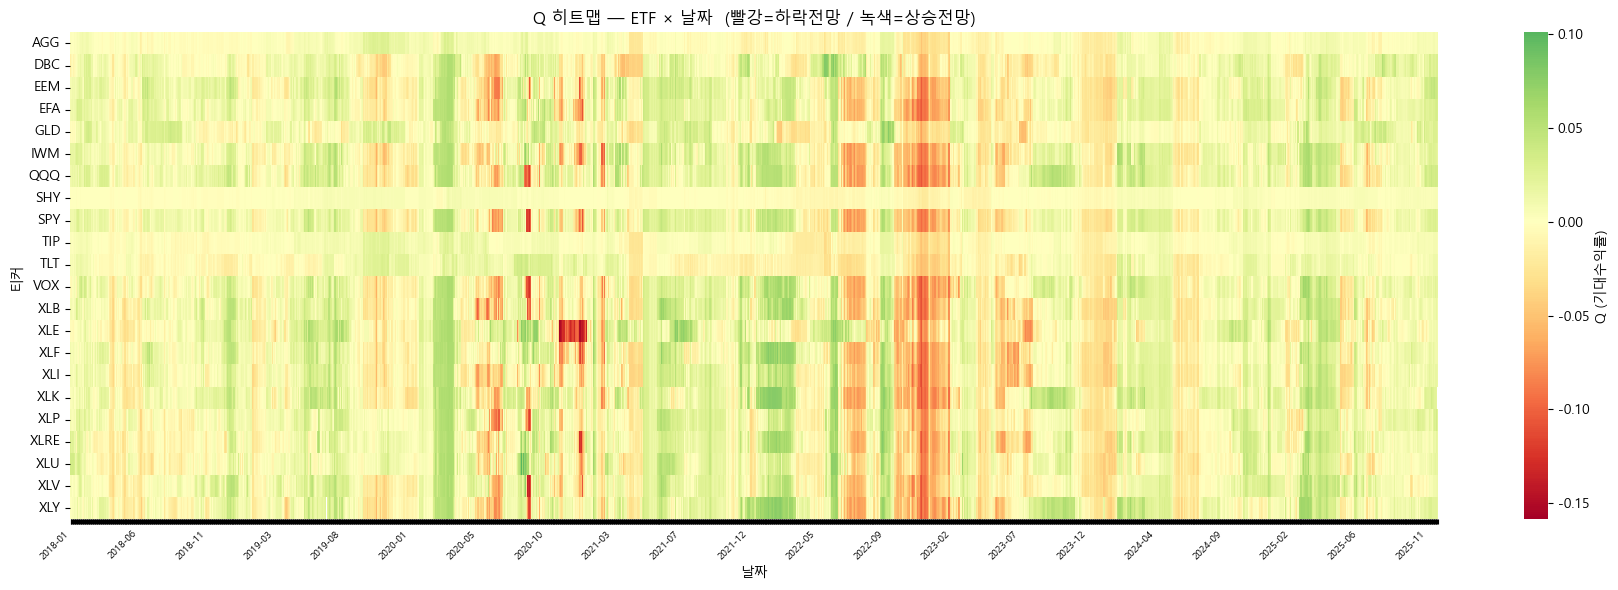

In [13]:
q_pivot = results_df["Q"].unstack("ticker")

n_hm = len(q_pivot)
step = max(1, n_hm // 20)
xlabels = [str(d)[:7] if i % step == 0 else ""
           for i, d in enumerate(q_pivot.index)]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(q_pivot.T, cmap="RdYlGn", center=0, ax=ax,
            xticklabels=xlabels, yticklabels=True,
            cbar_kws={"label": "Q (기대수익률)"})
ax.set_title("Q 히트맵 — ETF × 날짜  (빨강=하락전망 / 녹색=상승전망)", fontsize=12)
ax.set_xlabel("날짜"); ax.set_ylabel("티커")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgb_Q_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

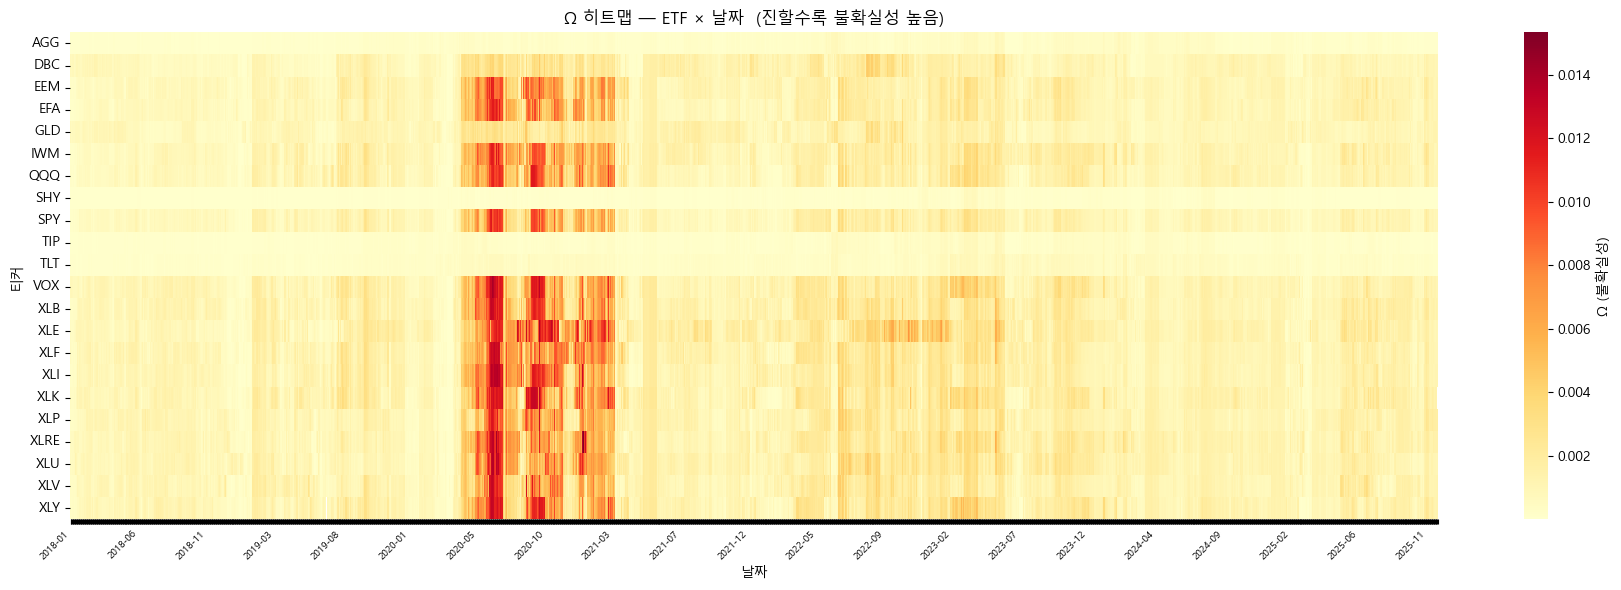

In [14]:
omega_pivot = results_df["Omega"].unstack("ticker")

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(omega_pivot.T, cmap="YlOrRd", ax=ax,
            xticklabels=xlabels, yticklabels=True,
            cbar_kws={"label": "Ω (불확실성)"})
ax.set_title("Ω 히트맵 — ETF × 날짜  (진할수록 불확실성 높음)", fontsize=12)
ax.set_xlabel("날짜"); ax.set_ylabel("티커")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgb_Omega_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. 피처 중요도 (마지막 윈도우 기준)

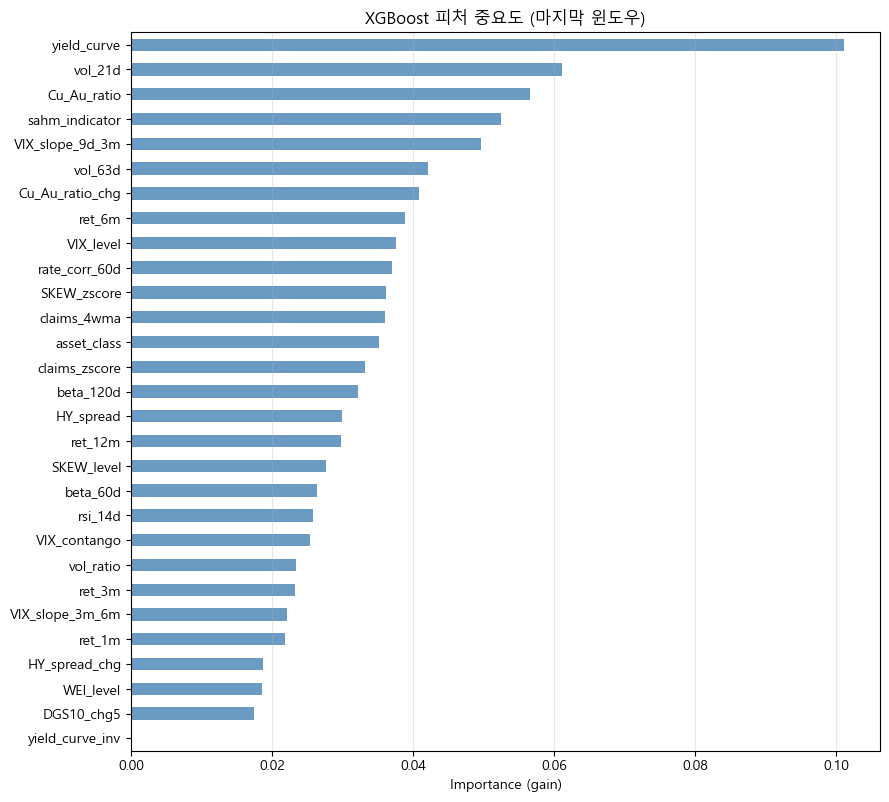


[상위 10 피처]
yield_curve        0.101168
vol_21d            0.061138
Cu_Au_ratio        0.056589
sahm_indicator     0.052431
VIX_slope_9d_3m    0.049667
vol_63d            0.042132
Cu_Au_ratio_chg    0.040757
ret_6m             0.038898
VIX_level          0.037626
rate_corr_60d      0.036947


In [15]:
if final_model is not None:
    feat_names = list(final_model.feature_names_in_)
    importance = (pd.Series(final_model.feature_importances_, index=feat_names)
                  .sort_values(ascending=True))

    fig, ax = plt.subplots(figsize=(9, max(6, len(feat_names) * 0.28)))
    importance.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
    ax.set_title(f"XGBoost 피처 중요도 (마지막 윈도우)", fontsize=12)
    ax.set_xlabel("Importance (gain)"); ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "xgb_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n[상위 10 피처]")
    print(importance.sort_values(ascending=False).head(10).to_string())

## 13. BL 입력용 Q, Ω 최종 저장

`Step 3-2 Black-Litterman` 노트북에서 바로 사용할 수 있도록
**(date × ticker)** 피벗 형태로 저장한다.


In [16]:
Q_bl     = results_df["Q"].unstack("ticker")
Omega_bl = results_df["Omega"].unstack("ticker")

Q_bl.to_parquet(OUTPUT_DIR / "Q_xgb.parquet")
Omega_bl.to_parquet(OUTPUT_DIR / "Omega_xgb.parquet")

print("=" * 50)
print("✅ BL 입력 파일 저장 완료")
print(f"  Q_xgb.parquet     shape: {Q_bl.shape}")
print(f"  Omega_xgb.parquet shape: {Omega_bl.shape}")
print(f"  저장 위치: {OUTPUT_DIR.resolve()}")
print("\n[Q 마지막 5 날짜 샘플]")
Q_bl.tail()

✅ BL 입력 파일 저장 완료
  Q_xgb.parquet     shape: (2058, 22)
  Omega_xgb.parquet shape: (2058, 22)
  저장 위치: C:\workspace\camp\project\finance_project\서윤범\outputs\step3

[Q 마지막 5 날짜 샘플]


ticker,AGG,DBC,EEM,EFA,GLD,IWM,QQQ,SHY,SPY,TIP,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
date,,,,,,,,,,,,,,,,,,,,,
2025-12-04,0.009601,0.026997,0.045217,0.032106,0.026795,0.028468,0.032480,0.005712,0.027916,0.008979,...,0.013204,0.012396,0.013638,0.014870,0.023062,0.028773,0.016213,0.016475,0.012783,0.023541
2025-12-05,0.007203,0.025560,0.039457,0.032108,0.029548,0.025377,0.036667,0.006135,0.029938,0.009448,...,0.014320,0.009834,0.011085,0.017640,0.023033,0.027830,0.014306,0.020447,0.011115,0.023228
2025-12-08,0.007390,0.028510,0.039114,0.033891,0.028343,0.023102,0.035495,0.005794,0.026327,0.009607,...,0.018517,0.013051,0.011949,0.017530,0.020909,0.034541,0.020655,0.017319,0.013351,0.023281
2025-12-09,0.007392,0.028373,0.038984,0.034677,0.028517,0.025164,0.035233,0.005799,0.026828,0.009242,...,0.025567,0.011960,0.013260,0.015844,0.022693,0.028971,0.020051,0.017263,0.015394,0.022761
2025-12-10,0.008225,0.027941,0.034795,0.031895,0.022608,0.018948,0.033257,0.005144,0.024401,0.006625,...,0.012551,0.010446,0.010904,0.014969,NaN,0.024227,0.016480,0.017164,0.013991,0.020653


In [17]:
Omega_bl.tail()

ticker,AGG,DBC,EEM,EFA,GLD,IWM,QQQ,SHY,SPY,TIP,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
date,,,,,,,,,,,,,,,,,,,,,
2025-12-04,0.000096,0.001082,0.000936,0.001103,0.001285,0.000960,0.001010,0.000041,0.000901,0.000087,...,0.001370,0.001034,0.001086,0.001054,0.001524,0.001798,0.001516,0.001096,0.001097,0.001382
2025-12-05,0.000065,0.001005,0.000987,0.001131,0.001345,0.000885,0.001026,0.000042,0.000973,0.000089,...,0.001219,0.000921,0.001053,0.001191,0.001446,0.001838,0.001447,0.001033,0.001164,0.001246
2025-12-08,0.000065,0.001054,0.001081,0.001149,0.001268,0.000997,0.001041,0.000039,0.000954,0.000091,...,0.001396,0.001023,0.001065,0.001177,0.001423,0.001747,0.001447,0.001012,0.001252,0.001346
2025-12-09,0.000066,0.000981,0.000960,0.001105,0.001249,0.000899,0.001105,0.000038,0.000954,0.000089,...,0.001428,0.001008,0.001060,0.000963,0.001532,0.001837,0.001497,0.001027,0.001350,0.001363
2025-12-10,0.000079,0.000997,0.001193,0.001183,0.001071,0.001140,0.001099,0.000037,0.000974,0.000057,...,0.001221,0.001009,0.001041,0.001155,NaN,0.001828,0.001459,0.001047,0.001321,0.001337


## 14. 다음 단계

| 단계 | 작업 | 파일 |
|------|------|------|
| Step 3-1 (B) | Random Forest → Q_rf, Ω_rf | `Step3_RF_WalkForward.ipynb` |
| Step 3-1 (C) | LLM Agent → Q_llm, Ω_llm | `Step3_LLM_Agent.ipynb` |
| Step 3-2 | 모델별 성과 비교 + Diebold-Mariano 검정 → 최적 Q, Ω 선택 | `Step3_Model_Selection.ipynb` |
| Step 3-3 | Black-Litterman → μ_BL, Σ_BL | `Step3_BlackLitterman.ipynb` |
| Step 3-4 | MVO (γ별) → 성향별 최적 비중 w* | `Step3_MVO.ipynb` |

---

> **모델 선택 기준 (Step 3-2)**
> RF / XGBoost / TabPFN 각각의 OOS Accuracy, R²_oos, Sharpe(τ* 그리드서치)를
> 독립적으로 비교한 뒤, 가장 우수한 단일 모델의 Q, Ω를 BL에 투입한다.
> (무조건 앙상블 시 신호 상쇄 → 시장 추종으로 수렴 위험)
